# TF-IDF

In [ ]:
!pip install gensim

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE

from gensim.models import Word2Vec
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
def load_data(filepath):
    df = pd.read_csv(filepath)
    print("✅ Data berhasil dibaca.")
    print(df.head())
    print("\nJumlah data:", df.shape)
    return df

df = load_data("/content/berita_detik_nasional_internasional.csv")


✅ Data berhasil dibaca.
  source  kategori                                                url  \
0  detik  nasional  https://news.detik.com/berita/d-8141021/1-jena...   
1  detik  nasional  https://news.detik.com/berita/d-8141018/siswi-...   
2  detik  nasional  https://news.detik.com/berita/d-8140924/jawab-...   
3  detik  nasional  https://news.detik.com/berita/d-8141016/bejat-...   
4  detik  nasional  https://news.detik.com/berita/d-8140970/menkum...   

                                               title  \
0  1 Jenazah Santri Korban Runtuhan Ponpes Sidoar...   
1  Siswi di Bandung Barat Meninggal Diduga Keracu...   
2  Jawab Kebingungan Umat, Ini Klasifikasi Produk...   
3  Bejat! Duo Kakek Kembar di Bekasi Lecehkan Wan...   
4  Menkum Resmi Teken SK Kepengurusan PPP Ketum M...   

                      published  \
0  Kamis, 02 Okt 2025 11:01 WIB   
1  Kamis, 02 Okt 2025 11:00 WIB   
2  Kamis, 02 Okt 2025 11:00 WIB   
3  Kamis, 02 Okt 2025 10:59 WIB   
4  Kamis, 02 Okt 2025 10:

In [ ]:
def clean_text(text):
    if pd.isnull(text):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def preprocess_data(df, text_column):
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()
    stop_words = set(stopwords.words('indonesian'))

    def light_preprocess(text):
        text = clean_text(text)
        tokens = text.split()
        # Keep stopwords if they are longer than 3 characters
        tokens = [stemmer.stem(t) for t in tokens if t not in stop_words or len(t) > 3]
        return " ".join(tokens)

    # Apply preprocessing to the specified text column
    df['processed_text'] = df[text_column].astype(str).apply(light_preprocess)
    print("✅ Data berhasil dibersihkan.")
    print("\nContoh hasil:\n", df['processed_text'].iloc[0])
    return df

# Call preprocess_data with the correct text column name
df = preprocess_data(df, "body")

✅ Data berhasil dibersihkan.

Contoh hasil:
 satu jenazah korban runtuh bangun ponpes al khozinysidoarjo jawa timur belum identifikasi korban temu dalam posisi sujud belah haikal yang hasil selamat sar mission coordinator smc yudhi bramantyo jelas korban tinggal tanpa identitas hasil keluar dari runtuh bangun sekitar pukul wib rabu awal tugas hendak evakuasi haikal namun nyata posisi dekat dengan korban yang tinggal dunia sehingga harus evakuasi lebih dahulu sujud yang tadi sore yang hitam yang belah sama haikal kita tadi ambil karena tidak bisa harus lewat situ akhir kita tarik yang ujar bramantyo seperti dilansirdetikjatim lama selang pukul wib tugas baru hasil evakuasi haikal selaku korban nyata selamat sudah kita evakuasi dalam kondisi selamat atau merah lanjut kita rujuk rumah sakit umum daerah sidoarjo tutur bramantyo baca selengkapnyadi sini


In [ ]:
def split_data(df, text_col="processed_text", label_col="kategori"):
    X_train, X_test, y_train, y_test = train_test_split(
        df[text_col], df[label_col], test_size=0.2, random_state=42, stratify=df[label_col]
    )
    print("✅ Data dibagi menjadi training dan testing.")
    print("Train:", len(X_train), "Test:", len(X_test))
    return X_train, X_test, y_train, y_test

# Call split_data with the correct column names
X_train, X_test, y_train, y_test = split_data(df, text_col="processed_text", label_col="kategori")

✅ Data dibagi menjadi training dan testing.
Train: 320 Test: 80


In [ ]:
def extract_tfidf_features(texts):
    vectorizer = TfidfVectorizer(
        max_features=25000,
        ngram_range=(1,2),
        sublinear_tf=True,
        norm='l2'
    )
    X_tfidf = vectorizer.fit_transform(texts)
    print("✅ TF-IDF selesai dibuat.")
    print("Shape:", X_tfidf.shape)
    print("Kata unik:", len(vectorizer.get_feature_names_out()))
    return X_tfidf, vectorizer

X_tfidf, vectorizer = extract_tfidf_features(X_train)


✅ TF-IDF selesai dibuat.
Shape: (320, 25000)
Kata unik: 25000


In [ ]:
def extract_word2vec_features(texts, vector_size=300):
    tokenized = [t.split() for t in texts]
    model_w2v = Word2Vec(
        sentences=tokenized,
        vector_size=vector_size,
        window=7,
        min_count=1,
        sg=0,     # CBOW
        workers=4,
        epochs=10
    )
    print("✅ Word2Vec (CBOW) selesai dilatih.")
    print("Jumlah kata dalam model:", len(model_w2v.wv))

    def doc_vector(tokens):
        valid = [w for w in tokens if w in model_w2v.wv]
        if not valid:
            return np.zeros(vector_size)
        return np.mean(model_w2v.wv[valid], axis=0)

    X_w2v = np.array([doc_vector(t) for t in tokenized])
    print("Shape Word2Vec:", X_w2v.shape)
    return X_w2v, model_w2v

X_w2v, model_w2v = extract_word2vec_features(X_train)


✅ Word2Vec (CBOW) selesai dilatih.
Jumlah kata dalam model: 5355
Shape Word2Vec: (320, 300)


In [ ]:
from scipy.sparse import hstack

def combine_features(X_tfidf, X_w2v):
    # Konversi Word2Vec ke sparse matrix agar bisa digabung
    from scipy import sparse
    X_combined = hstack([X_tfidf, sparse.csr_matrix(X_w2v)])
    print("✅ Fitur gabungan selesai dibuat.")
    print("Shape akhir:", X_combined.shape)
    return X_combined

X_combined = combine_features(X_tfidf, X_w2v)


✅ Fitur gabungan selesai dibuat.
Shape akhir: (320, 25300)


✅ Fitur gabungan selesai dibuat.
Shape akhir: (80, 25300)
🔧 Melakukan SMOTE balancing...
Data setelah SMOTE: (320, 25300)
🔥 Best Params: {'C': 0.1, 'solver': 'liblinear'}
📊 Cross-Validation Accuracy: 0.33125

✅ Akurasi Akhir: 23.75%

=== Classification Report ===
               precision    recall  f1-score   support

internasional       0.26      0.28      0.27        40
     nasional       0.22      0.20      0.21        40

     accuracy                           0.24        80
    macro avg       0.24      0.24      0.24        80
 weighted avg       0.24      0.24      0.24        80



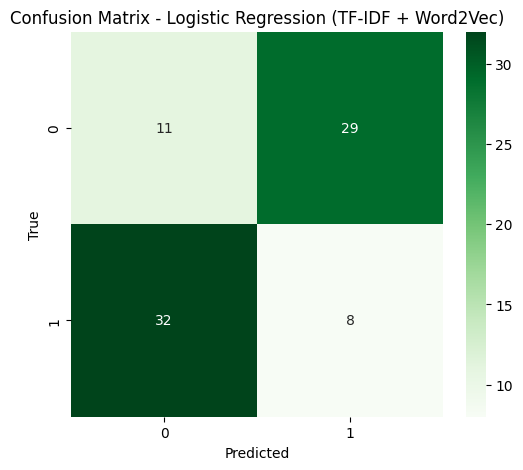

In [ ]:
def train_and_evaluate(X_train, X_test, y_train, y_test):
    print("🔧 Melakukan SMOTE balancing...")
    sm = SMOTE(random_state=42)
    X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)
    print("Data setelah SMOTE:", X_train_bal.shape)

    param_grid = {'C': [0.1, 1, 10], 'solver': ['liblinear', 'lbfgs']}
    grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5, scoring='accuracy')
    grid.fit(X_train_bal, y_train_bal)

    print("🔥 Best Params:", grid.best_params_)
    print("📊 Cross-Validation Accuracy:", grid.best_score_)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f"\n✅ Akurasi Akhir: {acc*100:.2f}%")
    print("\n=== Classification Report ===")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
    plt.title("Confusion Matrix - Logistic Regression (TF-IDF + Word2Vec)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

train_and_evaluate(X_combined, combine_features(
    vectorizer.transform(X_test), np.array([np.mean([model_w2v.wv[w] for w in t.split() if w in model_w2v.wv], axis=0) if any(w in model_w2v.wv for w in t.split()) else np.zeros(300) for t in X_test])
), y_train, y_test)
